# Prédiction de souscription à un dépôt à terme
### Bank Marketing — classification binaire, de l'exploration au déploiement

**Question business :** parmi les clients appelés lors d'une campagne de télémarketing, lesquels vont souscrire à un dépôt à terme ? Savoir les repérer permet de concentrer les appels sur les clients les plus susceptibles d'accepter.

**Données :** `bank-full.csv` (UCI Bank Marketing, Moro et al., 2014), séparateur `;`, variable cible `y` (`yes` / `no`).

**Ce que fait ce notebook :**
1. Explorer les données et mesurer le déséquilibre des classes
2. Préparer les données **sans fuite d'information** (split d'abord, tout le reste dans un pipeline)
3. Comparer 7 modèles avec `GridSearchCV`, SMOTE appliqué uniquement sur les plis d'entraînement
4. Évaluer avec des métriques adaptées (Recall, Precision, F1, ROC-AUC, PR-AUC) et vérifier l'overfitting
5. Choisir le modèle, régler le seuil de décision, mesurer le gain business
6. Sauvegarder un pipeline unique utilisé par l'interface Streamlit (`app.py`)

> **Pour lancer le notebook :** place `bank-full.csv` dans le même dossier, puis *Run All*. Le tuning complet prend de quelques minutes à plus de 10 minutes selon la machine (le SVM est le plus lent).

## 1. Imports et configuration

In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    average_precision_score, f1_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, accuracy_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

# ── Paramètres du projet ──
DATA_PATH = "bank-full.csv"
RANDOM_STATE = 42
DROP_DURATION = True        # voir la section 4.3 : `duration` n'est pas connue avant l'appel
CV_FOLDS = 3                # plis de validation croisée pour GridSearchCV
TUNING_SAMPLE = 10_000      # taille de l'échantillon pour le tuning des modèles lents (SVM, MLP, KNN)
DEV_SUBSAMPLE = None        # mettre par ex. 8000 pour un test rapide du notebook
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

print("Environnement prêt — scikit-learn", sklearn.__version__)

Environnement prêt — scikit-learn 1.8.0


## 2. Business understanding

| Élément | Choix |
|---|---|
| Cible | `y = 1` si le client souscrit, `0` sinon |
| Coût d'un **faux négatif** | on rate un client qui aurait souscrit (manque à gagner) |
| Coût d'un **faux positif** | on appelle un client pour rien (temps de conseiller) |
| Métriques principales | **F1**, **Recall**, **Precision** sur la classe « oui », plus **PR-AUC** (robuste au déséquilibre) |

L'accuracy seule est trompeuse ici : un modèle qui répond toujours « non » est déjà juste environ 9 fois sur 10.

## 3. Data understanding

In [2]:
df = pd.read_csv(DATA_PATH, sep=";")
df.columns = df.columns.str.strip()

if DEV_SUBSAMPLE:
    df = df.sample(DEV_SUBSAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"{df.shape[0]:,} clients, {df.shape[1] - 1} variables explicatives")
display(df.head())
df.info()

45,211 clients, 16 variables explicatives


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [3]:
# ── Contrôles qualité ──
print("Valeurs manquantes (NaN) :", int(df.isna().sum().sum()))
print("Lignes dupliquées        :", int(df.duplicated().sum()))

cat_cols_all = df.select_dtypes(exclude="number").columns.drop("y")
unknown_share = (df[cat_cols_all] == "unknown").mean()
unknown_share = unknown_share[unknown_share > 0].sort_values(ascending=False)
print("\nPart de modalités « unknown » (information manquante codée comme texte) :")
print((unknown_share * 100).round(1).astype(str) + " %")

Valeurs manquantes (NaN) : 0
Lignes dupliquées        : 0

Part de modalités « unknown » (information manquante codée comme texte) :
poutcome     81.7 %
contact      28.8 %
education     4.1 %
job           0.6 %
dtype: str


Non : 39,922 | Oui : 5,289  ->  7.5 « non » pour 1 « oui » (11.7% de souscripteurs)


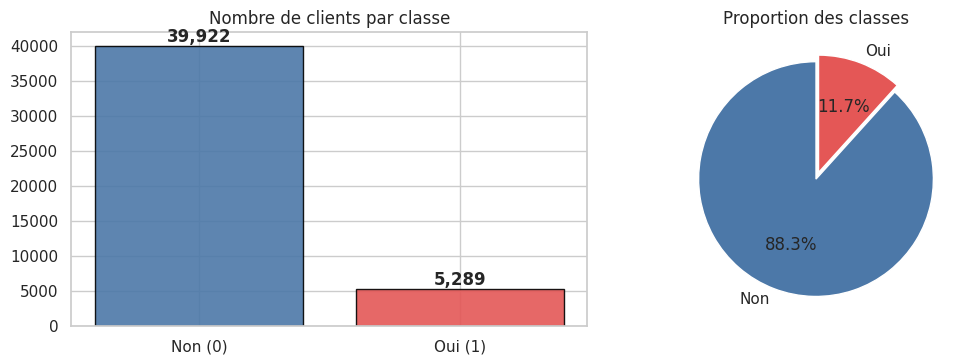

In [4]:
# ── Encodage de la cible ──
df["y"] = df["y"].str.strip().str.lower().map({"yes": 1, "no": 0})
assert df["y"].notna().all(), "Valeurs inattendues dans la cible"

counts = df["y"].value_counts().sort_index()
ratio = counts[0] / counts[1]
print(f"Non : {counts[0]:,} | Oui : {counts[1]:,}  ->  {ratio:.1f} « non » pour 1 « oui » ({counts[1] / len(df):.1%} de souscripteurs)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(["Non (0)", "Oui (1)"], counts.values, color=["#4C78A8", "#E45756"], edgecolor="black", alpha=.9)
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Nombre de clients par classe")
axes[1].pie(counts.values, labels=["Non", "Oui"], colors=["#4C78A8", "#E45756"],
            autopct="%1.1f%%", startangle=90, explode=(0, .06))
axes[1].set_title("Proportion des classes")
plt.tight_layout(); plt.show()

### 3.1 Analyse exploratoire
Objectif : repérer quelles variables séparent les souscripteurs des autres, et quelles anomalies de données gérer.

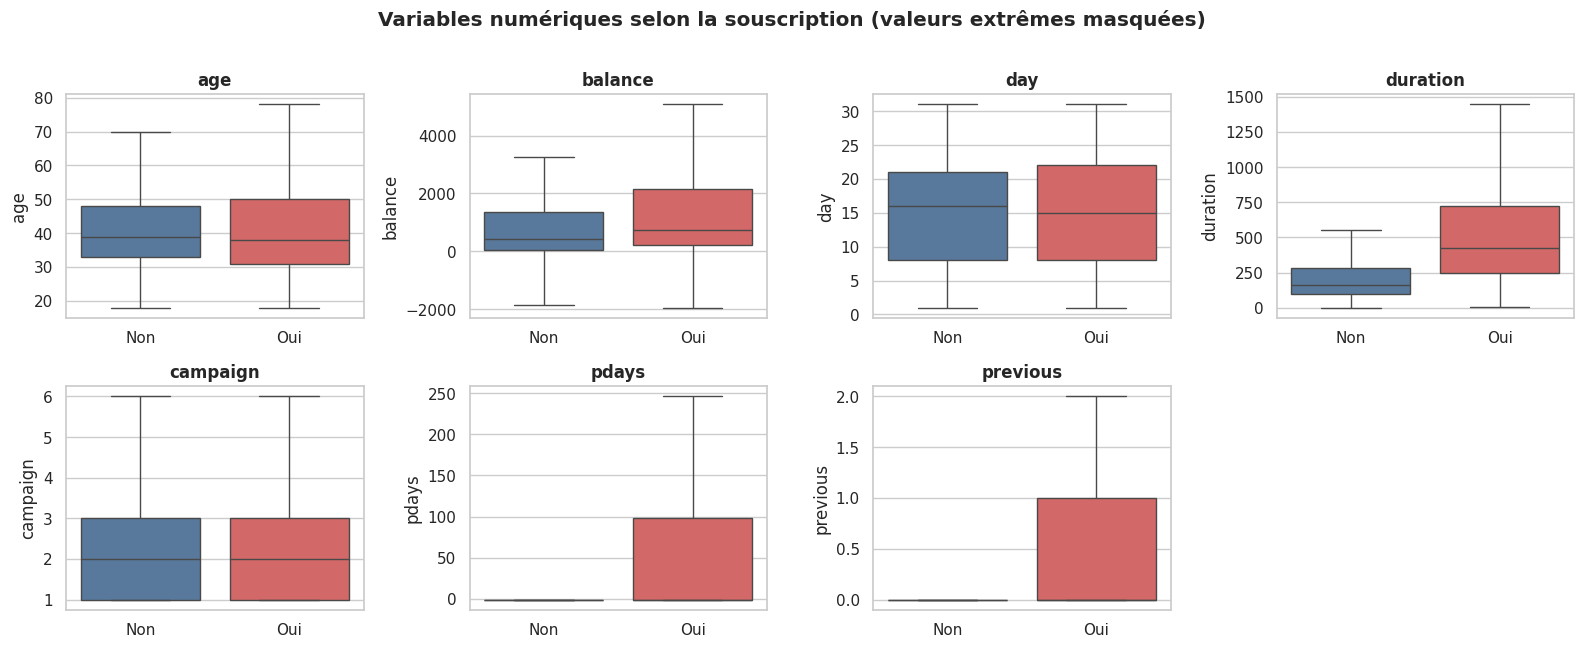

In [5]:
# ── Variables numériques selon la cible ──
num_cols_eda = df.select_dtypes(include="number").columns.drop("y").tolist()
n = len(num_cols_eda)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
for ax, col in zip(axes.flatten(), num_cols_eda):
    sns.boxplot(data=df, x="y", y=col, ax=ax, showfliers=False, palette=["#4C78A8", "#E45756"], hue="y", legend=False)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Non", "Oui"]); ax.set_xlabel("")
    ax.set_title(col, fontweight="bold")
for ax in axes.flatten()[n:]:
    ax.axis("off")
plt.suptitle("Variables numériques selon la souscription (valeurs extrêmes masquées)", y=1.01, fontweight="bold")
plt.tight_layout(); plt.show()

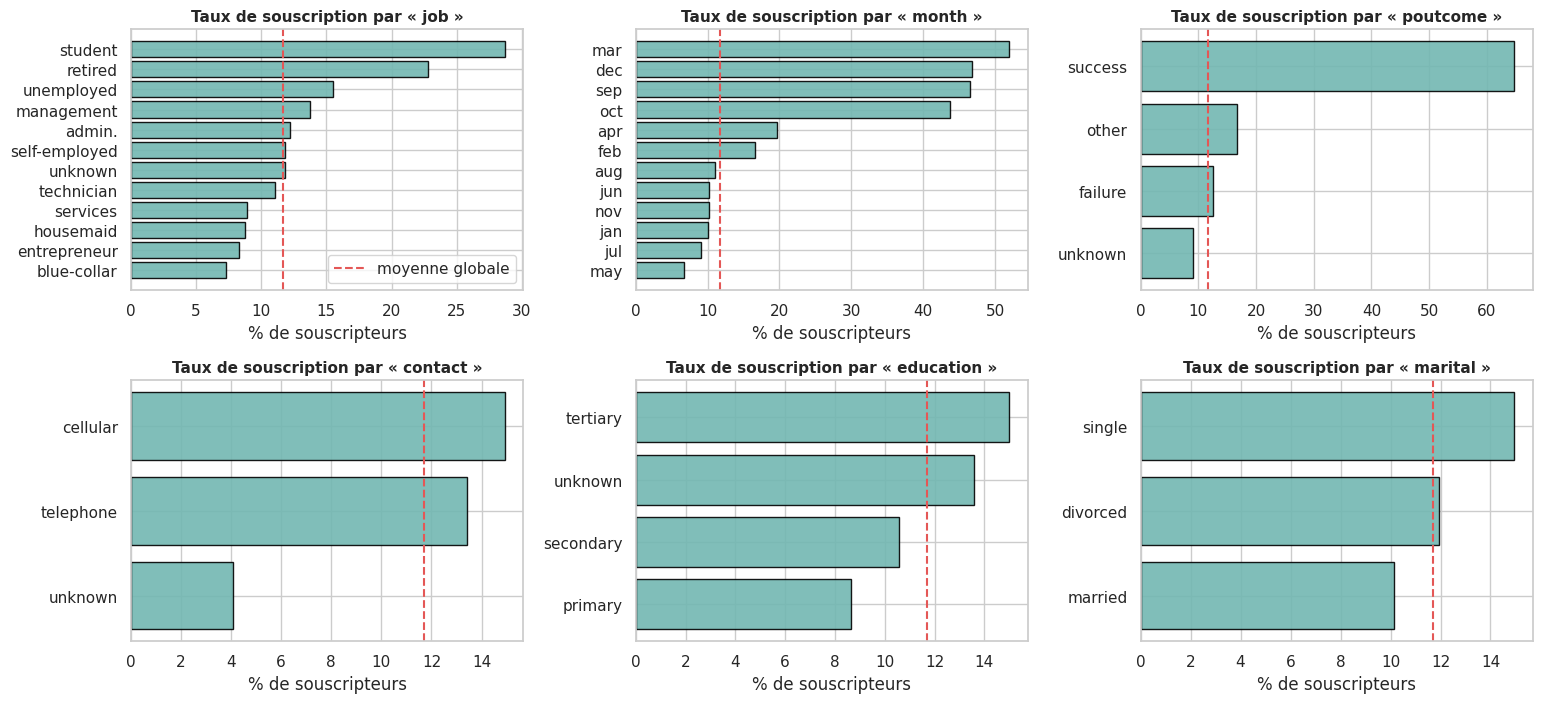

In [6]:
# ── Taux de souscription par modalité (variables catégorielles) ──
taux_global = df["y"].mean()
cols_cat_eda = [c for c in ["job", "month", "poutcome", "contact", "education", "marital"] if c in df.columns]
ncols = 3
nrows = int(np.ceil(len(cols_cat_eda) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows))
for ax, col in zip(np.array(axes).flatten(), cols_cat_eda):
    t = df.groupby(col)["y"].mean().sort_values()
    ax.barh(t.index, t.values * 100, color="#72B7B2", edgecolor="black", alpha=.9)
    ax.axvline(taux_global * 100, color="#E45756", ls="--", lw=1.5, label="moyenne globale")
    ax.set_title(f"Taux de souscription par « {col} »", fontsize=11, fontweight="bold")
    ax.set_xlabel("% de souscripteurs")
axes_flat = np.array(axes).flatten()
axes_flat[0].legend(loc="lower right")
for ax in axes_flat[len(cols_cat_eda):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

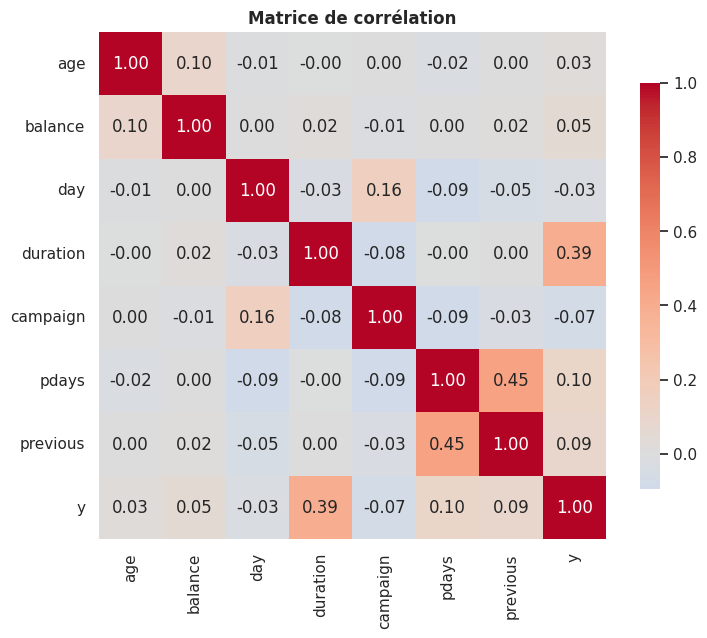

Corrélation avec la cible :
duration    0.395
pdays       0.104
previous    0.093
campaign   -0.073
balance     0.053
day        -0.028
age         0.025


In [7]:
# ── Corrélations (numériques + cible) ──
corr = df.select_dtypes(include="number").corr()
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Matrice de corrélation", fontweight="bold")
plt.tight_layout(); plt.show()

print("Corrélation avec la cible :")
print(corr["y"].drop("y").sort_values(key=abs, ascending=False).round(3).to_string())

In [8]:
# ── Lecture automatique : meilleurs segments (au moins 100 clients) ──
for col in [c for c in ["job", "month", "poutcome"] if c in df.columns]:
    t = (df.groupby(col)["y"].agg(taux="mean", effectif="size")
           .query("effectif >= 100").sort_values("taux", ascending=False).head(3))
    segments = ", ".join(f"{idx} ({r.taux:.0%})" for idx, r in t.iterrows())
    print(f"{col:<10}: segments les plus convertissants -> {segments}")
print(f"\nTaux global de souscription : {taux_global:.1%}")
if "pdays" in df.columns and (df["pdays"] == -1).any():
    print(f"pdays = -1 (client jamais contacté avant) : {(df['pdays'] == -1).mean():.0%} des clients — ce n'est pas une vraie durée, c'est un code « pas de contact précédent ».")

job       : segments les plus convertissants -> student (29%), retired (23%), unemployed (16%)
month     : segments les plus convertissants -> mar (52%), dec (47%), sep (46%)
poutcome  : segments les plus convertissants -> success (65%), other (17%), failure (13%)

Taux global de souscription : 11.7%
pdays = -1 (client jamais contacté avant) : 82% des clients — ce n'est pas une vraie durée, c'est un code « pas de contact précédent ».


## 4. Data preparation

Règle d'or de ce notebook : **on sépare train/test d'abord**, puis toutes les transformations (scaling, encodage, SMOTE) sont apprises **uniquement sur le train**, à l'intérieur d'un `Pipeline`. Ainsi, pendant la validation croisée, le scaler, l'encodeur et SMOTE sont recalculés sur chaque pli d'entraînement et ne voient jamais le pli de validation.

### 4.1 Split stratifié train / test
`stratify=y` conserve la même proportion de souscripteurs dans les deux jeux, indispensable avec des classes déséquilibrées.

In [9]:
y = df["y"]
X_all = df.drop(columns="y")

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train : {X_train_all.shape[0]:,} lignes ({y_train.mean():.1%} de « oui »)")
print(f"Test  : {X_test_all.shape[0]:,} lignes ({y_test.mean():.1%} de « oui »)")

Train : 36,168 lignes (11.7% de « oui »)
Test  : 9,043 lignes (11.7% de « oui »)


### 4.2 Pré-traitement (dans un `ColumnTransformer`)
- Variables numériques → `StandardScaler`
- Variables catégorielles → `OneHotEncoder(handle_unknown="ignore")` (une modalité inconnue en production ne fait pas planter le modèle)

In [10]:
def build_preprocessor(X):
    """Construit le pré-traitement à partir des types de colonnes de X."""
    num = X.select_dtypes(include="number").columns.tolist()
    cat = X.select_dtypes(exclude="number").columns.tolist()
    return ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat),
    ])

print("Pré-traitement défini")

Pré-traitement défini


### 4.3 Le piège de la variable `duration`
`duration` est la durée de l'appel, en secondes. Elle n'est connue **qu'après** l'appel, donc impossible à utiliser pour décider *qui appeler*. Elle est aussi mécaniquement liée au résultat : un client qui refuse raccroche vite. La documentation du dataset recommande de l'exclure pour un modèle prédictif réaliste.

On le vérifie : même modèle, avec et sans `duration`.

,ROC-AUC,PR-AUC
Avec duration (irréaliste),0.930,0.619
Sans duration (réaliste),0.803,0.453


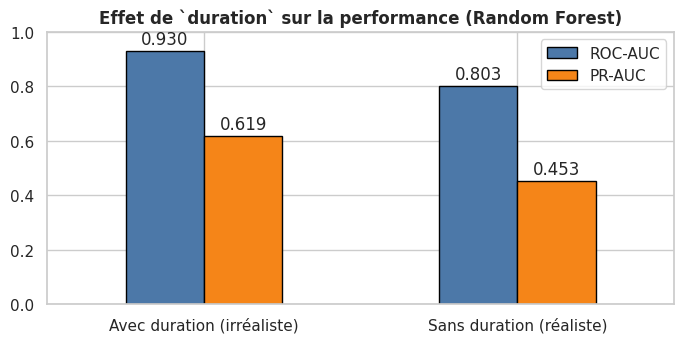

In [11]:
def quick_eval(drop_cols):
    X_tr = X_train_all.drop(columns=drop_cols, errors="ignore")
    X_te = X_test_all.drop(columns=drop_cols, errors="ignore")
    pipe = Pipeline([
        ("prep", build_preprocessor(X_tr)),
        ("rf", RandomForestClassifier(n_estimators=150, min_samples_leaf=5, class_weight="balanced",
                                      n_jobs=-1, random_state=RANDOM_STATE)),
    ])
    pipe.fit(X_tr, y_train)
    p = pipe.predict_proba(X_te)[:, 1]
    return {"ROC-AUC": roc_auc_score(y_test, p), "PR-AUC": average_precision_score(y_test, p)}

if "duration" in X_train_all.columns:
    cmp_duration = pd.DataFrame({
        "Avec duration (irréaliste)": quick_eval([]),
        "Sans duration (réaliste)": quick_eval(["duration"]),
    }).T
    display(cmp_duration.round(3))
    ax = cmp_duration.plot.bar(rot=0, figsize=(7, 3.6), edgecolor="black", color=["#4C78A8", "#F58518"])
    ax.set_ylim(0, 1); ax.set_title("Effet de `duration` sur la performance (Random Forest)", fontweight="bold")
    for c in ax.containers:
        ax.bar_label(c, fmt="%.3f", padding=2)
    plt.tight_layout(); plt.show()
else:
    print("Pas de colonne `duration` dans ce fichier.")

**Résultat :** retirer `duration` fait passer le ROC-AUC de **0,93 à 0,80** et la PR-AUC de **0,62 à 0,45**. Le score « avec duration » était donc largement gonflé par une information indisponible avant l'appel. Le notebook retire la colonne (`DROP_DURATION = True`) : on préfère un modèle moins brillant mais **utilisable en vrai**.

In [12]:
drop_cols = ["duration"] if DROP_DURATION else []
X_train = X_train_all.drop(columns=drop_cols, errors="ignore")
X_test = X_test_all.drop(columns=drop_cols, errors="ignore")

print(f"Variables utilisées ({X_train.shape[1]}) : {X_train.columns.tolist()}")

Variables utilisées (15) : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']


### 4.4 Déséquilibre : SMOTE dans le pipeline
SMOTE crée des exemples synthétiques de la classe minoritaire en interpolant entre voisins. Il est placé **dans** le pipeline, après le pré-traitement : il n'agit que sur les données d'entraînement de chaque pli, jamais à la prédiction.

*Limite à connaître :* appliqué après One-Hot Encoding, SMOTE interpole aussi les colonnes 0/1 (valeurs fractionnaires). `SMOTENC` serait plus rigoureux ; on garde SMOTE pour rester simple et comparable.

In [13]:
def make_pipe(model):
    return ImbPipeline([
        ("prep", build_preprocessor(X_train)),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model),
    ])

# Illustration : effet de SMOTE sur le train (le pipeline le refait proprement à chaque pli)
Xt = build_preprocessor(X_train).fit_transform(X_train)
_, y_sm = SMOTE(random_state=RANDOM_STATE).fit_resample(Xt, y_train)
print(f"Avant SMOTE : non = {(y_train == 0).sum():,} | oui = {(y_train == 1).sum():,}")
print(f"Après SMOTE : non = {(y_sm == 0).sum():,} | oui = {(y_sm == 1).sum():,}")
del Xt, y_sm

Avant SMOTE : non = 31,937 | oui = 4,231
Après SMOTE : non = 31,937 | oui = 31,937


## 5. Modélisation

**Choix d'optimisation :** `GridSearchCV` avec `scoring="f1"` (et non `recall`). Optimiser le recall seul pousse vers un modèle qui prédit « oui » pour tout le monde (recall = 1, précision très faible). Le F1 force un compromis entre clients détectés et appels inutiles. Le **seuil de décision** est ensuite ajusté séparément (section 8).

Pour les modèles lents (KNN, SVM, MLP), la grille est explorée sur un **échantillon stratifié** de `TUNING_SAMPLE` lignes, puis le meilleur modèle est ré-entraîné sur tout le train.

In [14]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results, models, scores = {}, {}, {}

# Sous-échantillon du train utilisé pour mesurer l'overfitting rapidement
idx_check = X_train.sample(min(10_000, len(X_train)), random_state=RANDOM_STATE).index


def score_vector(model, X):
    """Score continu de la classe « oui » (probabilité si disponible)."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def tune_and_eval(name, estimator, grid, sample_n=None):
    t0 = time.time()
    pipe = make_pipe(estimator)
    prefixed = ([{f"model__{k}": v for k, v in g.items()} for g in grid]
                if isinstance(grid, list) else {f"model__{k}": v for k, v in grid.items()})

    if sample_n and len(X_train) > sample_n:
        X_s, _, y_s, _ = train_test_split(X_train, y_train, train_size=sample_n,
                                          stratify=y_train, random_state=RANDOM_STATE)
    else:
        X_s, y_s = X_train, y_train

    gs = GridSearchCV(pipe, prefixed, cv=cv, scoring="f1", n_jobs=-1)
    gs.fit(X_s, y_s)

    best = clone(gs.best_estimator_)
    best.fit(X_train, y_train)                      # ré-entraînement sur tout le train

    y_pred = best.predict(X_test)
    s = score_vector(best, X_test)
    results[name] = {
        "cv_f1": gs.best_score_,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, s),
        "pr_auc": average_precision_score(y_test, s),
        "f1_train": f1_score(y_train.loc[idx_check], best.predict(X_train.loc[idx_check])),
        "temps_s": time.time() - t0,
    }
    models[name], scores[name] = best, s

    best_params = {k.replace("model__", ""): v for k, v in gs.best_params_.items()}
    r = results[name]
    print(f"{name}")
    print(f"  meilleurs paramètres : {best_params}")
    print(f"  F1 CV = {r['cv_f1']:.3f} | test : precision = {r['precision']:.3f}, recall = {r['recall']:.3f}, "
          f"F1 = {r['f1']:.3f}, PR-AUC = {r['pr_auc']:.3f}  ({r['temps_s']:.0f}s)")

print("Fonction de tuning prête")

Fonction de tuning prête


### 5.1 Régression logistique
Modèle de référence : simple, rapide, interprétable. `C` règle la force de régularisation, `penalty` son type (L1 sélectionne des variables, L2 réduit les coefficients).

In [15]:
tune_and_eval(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    {"C": [0.01, 0.1, 1, 10], "penalty": ["l1", "l2"], "solver": ["liblinear"]},
)

Logistic Regression
  meilleurs paramètres : {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
  F1 CV = 0.365 | test : precision = 0.258, recall = 0.630, F1 = 0.366, PR-AUC = 0.409  (16s)


### 5.2 K plus proches voisins (KNN)
Classe un client selon ses `k` voisins les plus proches. Très sensible à l'échelle des variables (d'où le `StandardScaler`) et lent sur de gros jeux : tuning sur échantillon.

In [16]:
tune_and_eval(
    "KNN",
    KNeighborsClassifier(),
    {"n_neighbors": [5, 11, 21], "weights": ["uniform", "distance"]},
    sample_n=TUNING_SAMPLE,
)

KNN
  meilleurs paramètres : {'n_neighbors': 5, 'weights': 'distance'}
  F1 CV = 0.332 | test : precision = 0.259, recall = 0.548, F1 = 0.352, PR-AUC = 0.260  (13s)


### 5.3 SVM : noyau RBF et noyau polynomial
Les deux noyaux sont comparés dans la **même** grille. Le SVM est le modèle le plus lent de ce notebook (complexité quadratique) ; il ne fournit pas de probabilités par défaut, il pourra donc être comparé mais pas déployé tel quel dans l'interface.

In [17]:
tune_and_eval(
    "SVM",
    SVC(),
    [
        {"kernel": ["rbf"], "C": [0.1, 1, 10], "gamma": ["scale", 0.01]},
        {"kernel": ["poly"], "C": [0.1, 1], "degree": [2, 3]},
    ],
    sample_n=TUNING_SAMPLE,
)

SVM
  meilleurs paramètres : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
  F1 CV = 0.418 | test : precision = 0.386, recall = 0.564, F1 = 0.459, PR-AUC = 0.427  (333s)


### 5.4 Réseau de neurones (MLP)
Perceptron multicouche. `alpha` régularise, `early_stopping=True` arrête l'entraînement quand le score de validation interne ne progresse plus (protection contre l'overfitting).

In [18]:
tune_and_eval(
    "MLP",
    MLPClassifier(max_iter=300, early_stopping=True, random_state=RANDOM_STATE),
    {
        "hidden_layer_sizes": [(50,), (100,), (50, 50)],
        "activation": ["relu", "tanh"],
        "alpha": [0.0001, 0.01],
    },
    sample_n=TUNING_SAMPLE,
)

MLP
  meilleurs paramètres : {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50,)}
  F1 CV = 0.374 | test : precision = 0.305, recall = 0.574, F1 = 0.398, PR-AUC = 0.380  (110s)


### 5.5 Arbre de décision
Très lisible : on peut lire les règles. Sans contrainte de profondeur il mémorise le train (overfitting), d'où la grille sur `max_depth` et `min_samples_leaf`.

In [19]:
tune_and_eval(
    "Decision Tree",
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {"max_depth": [3, 5, 7, 10], "min_samples_leaf": [1, 20, 50], "criterion": ["gini", "entropy"]},
)

Decision Tree
  meilleurs paramètres : {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 50}
  F1 CV = 0.394 | test : precision = 0.397, recall = 0.501, F1 = 0.443, PR-AUC = 0.358  (27s)


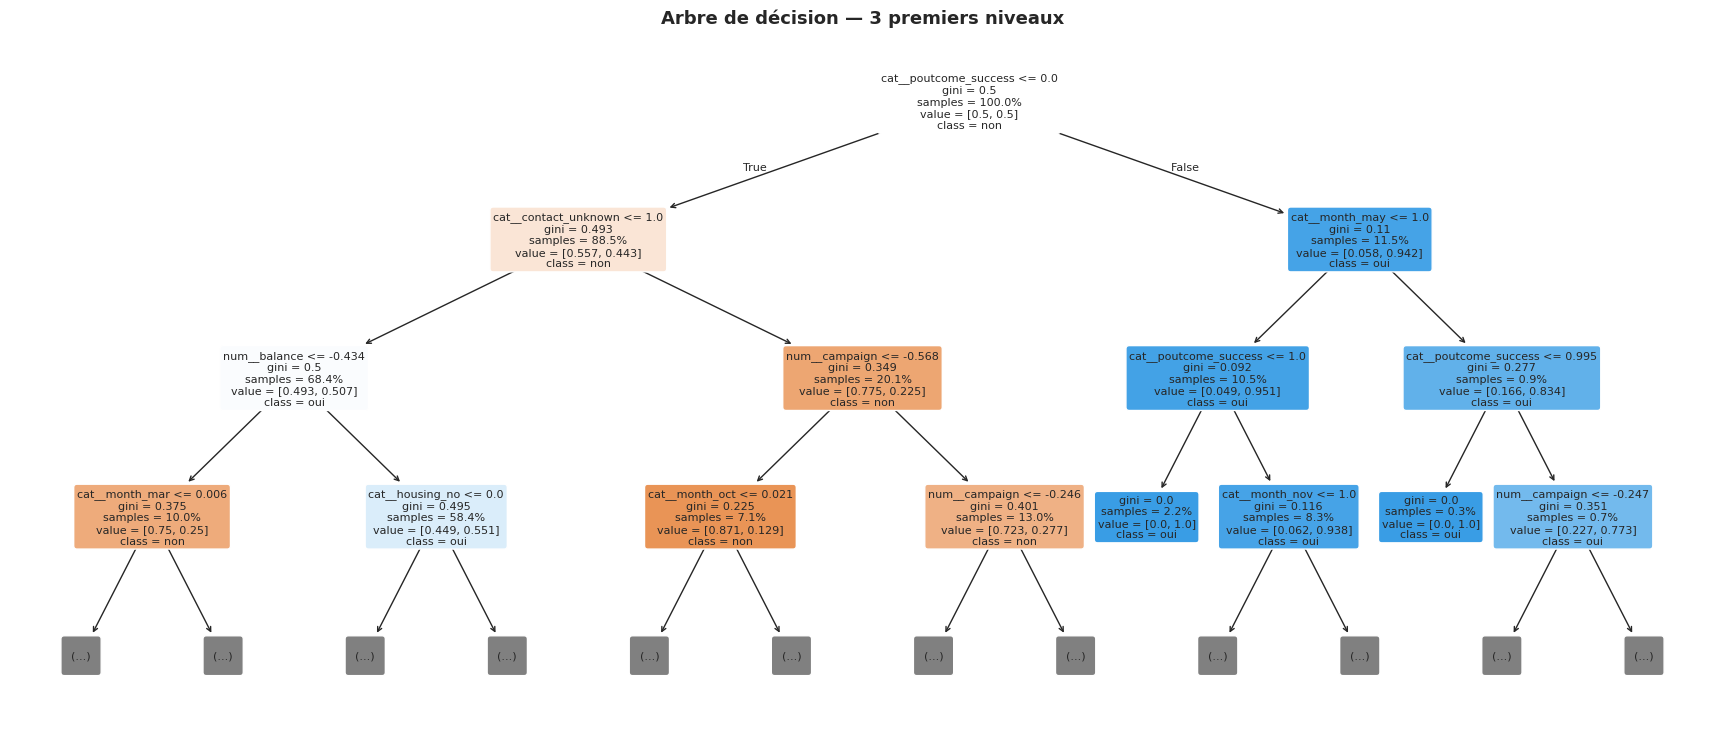

In [20]:
# Visualisation de l'arbre retenu (3 premiers niveaux pour rester lisible)
dt_pipe = models["Decision Tree"]
feat_names = dt_pipe.named_steps["prep"].get_feature_names_out()
plt.figure(figsize=(22, 9))
plot_tree(dt_pipe.named_steps["model"], feature_names=feat_names, class_names=["non", "oui"],
          filled=True, fontsize=8, max_depth=3, proportion=True, rounded=True)
plt.title("Arbre de décision — 3 premiers niveaux", fontsize=13, fontweight="bold")
plt.show()

### 5.6 Random Forest
Ensemble d'arbres entraînés sur des échantillons différents (bagging) : réduit la variance d'un arbre seul et reste robuste.

In [21]:
tune_and_eval(
    "Random Forest",
    RandomForestClassifier(random_state=RANDOM_STATE),
    {"n_estimators": [100, 200], "max_depth": [8, 12], "min_samples_leaf": [1, 5], "max_features": ["sqrt"]},
)

Random Forest
  meilleurs paramètres : {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
  F1 CV = 0.443 | test : precision = 0.409, recall = 0.512, F1 = 0.455, PR-AUC = 0.424  (138s)


### 5.7 Gradient Boosting (ajout)
Boosting d'arbres, souvent le meilleur choix sur des données tabulaires. `HistGradientBoostingClassifier` est rapide et natif scikit-learn.

In [22]:
tune_and_eval(
    "Gradient Boosting",
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    {"learning_rate": [0.05, 0.1], "max_depth": [3, 6], "max_iter": [200]},
)

Gradient Boosting
  meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 200}
  F1 CV = 0.427 | test : precision = 0.498, recall = 0.407, F1 = 0.448, PR-AUC = 0.422  (37s)


## 6. Comparaison des modèles
Tous les modèles sont évalués sur le **même jeu de test**, jamais utilisé pendant le tuning.

In [23]:
df_res = pd.DataFrame(results).T.sort_values("cv_f1", ascending=False)
display(df_res.round(3))

,cv_f1,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_train,temps_s
Random Forest,0.443,0.856,0.409,0.512,0.455,0.790,0.424,0.483,137.503
Gradient Boosting,0.427,0.883,0.498,0.407,0.448,0.785,0.422,0.448,36.782
SVM,0.418,0.844,0.386,0.564,0.459,0.785,0.427,0.464,332.579
Decision Tree,0.394,0.852,0.397,0.501,0.443,0.744,0.358,0.436,27.205
MLP,0.374,0.797,0.305,0.574,0.398,0.749,0.380,0.457,110.271
Logistic Regression,0.365,0.745,0.258,0.630,0.366,0.768,0.409,0.369,15.716
KNN,0.332,0.763,0.259,0.548,0.352,0.714,0.260,1.000,12.980


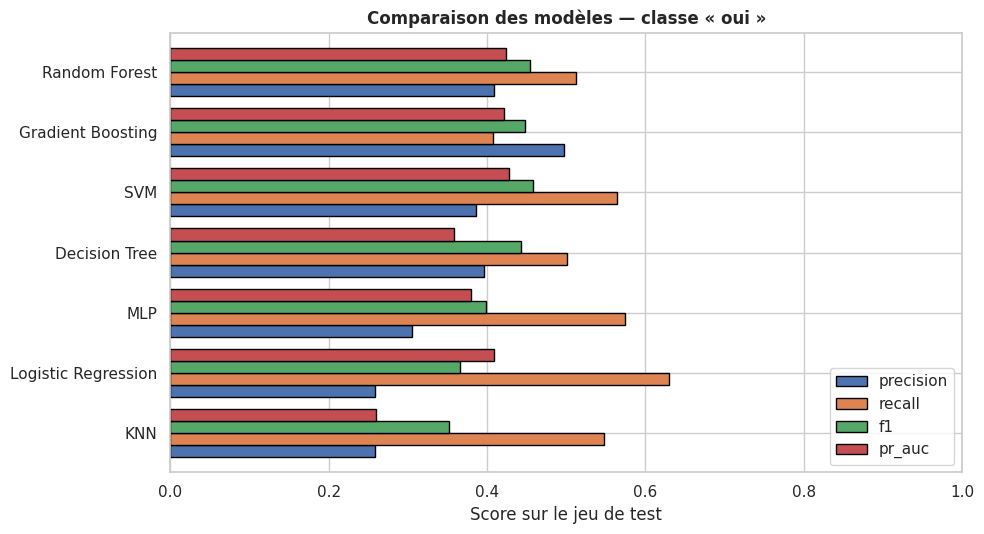

In [24]:
metriques = ["precision", "recall", "f1", "pr_auc"]
ax = df_res[metriques].iloc[::-1].plot.barh(figsize=(10, 5.5), edgecolor="black", width=.8)
ax.set_xlim(0, 1); ax.set_xlabel("Score sur le jeu de test")
ax.set_title("Comparaison des modèles — classe « oui »", fontweight="bold")
ax.legend(loc="lower right", title="")
plt.tight_layout(); plt.show()

**Lecture :** quatre modèles sont très proches (Random Forest, SVM, Gradient Boosting, arbre de décision : F1 entre 0,44 et 0,46 sur le test). Aucun ne domine nettement. 
La régression logistique a le recall le plus élevé (63 %) mais la précision la plus faible (26 %) : elle signale beaucoup de clients pour peu de souscriptions. Le KNN est le moins performant (PR-AUC 0,26).

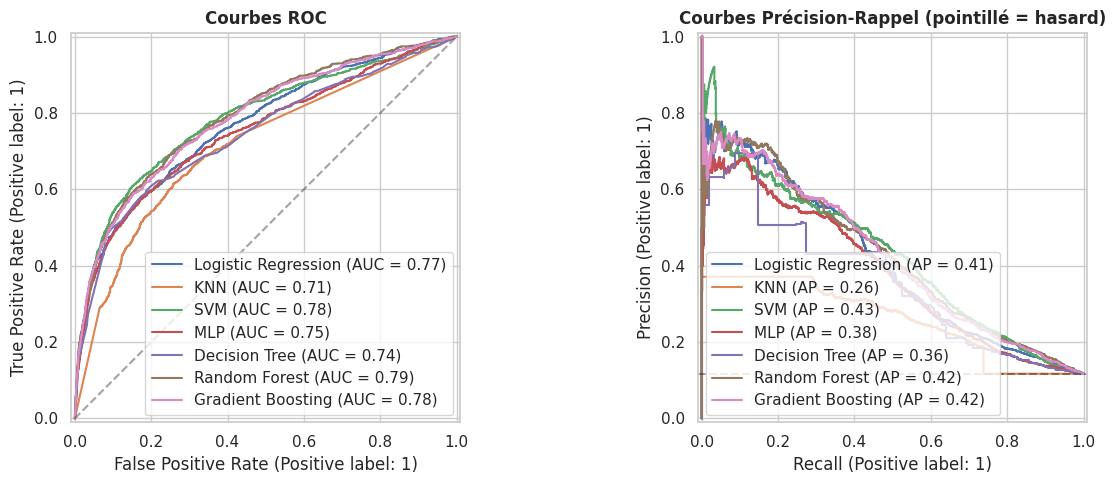

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for nom, s in scores.items():
    RocCurveDisplay.from_predictions(y_test, s, name=nom, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, s, name=nom, ax=axes[1])
axes[0].plot([0, 1], [0, 1], "k--", alpha=.4); axes[0].set_title("Courbes ROC", fontweight="bold")
axes[1].axhline(y_test.mean(), color="k", ls="--", alpha=.4)
axes[1].set_title("Courbes Précision-Rappel (pointillé = hasard)", fontweight="bold")
plt.tight_layout(); plt.show()

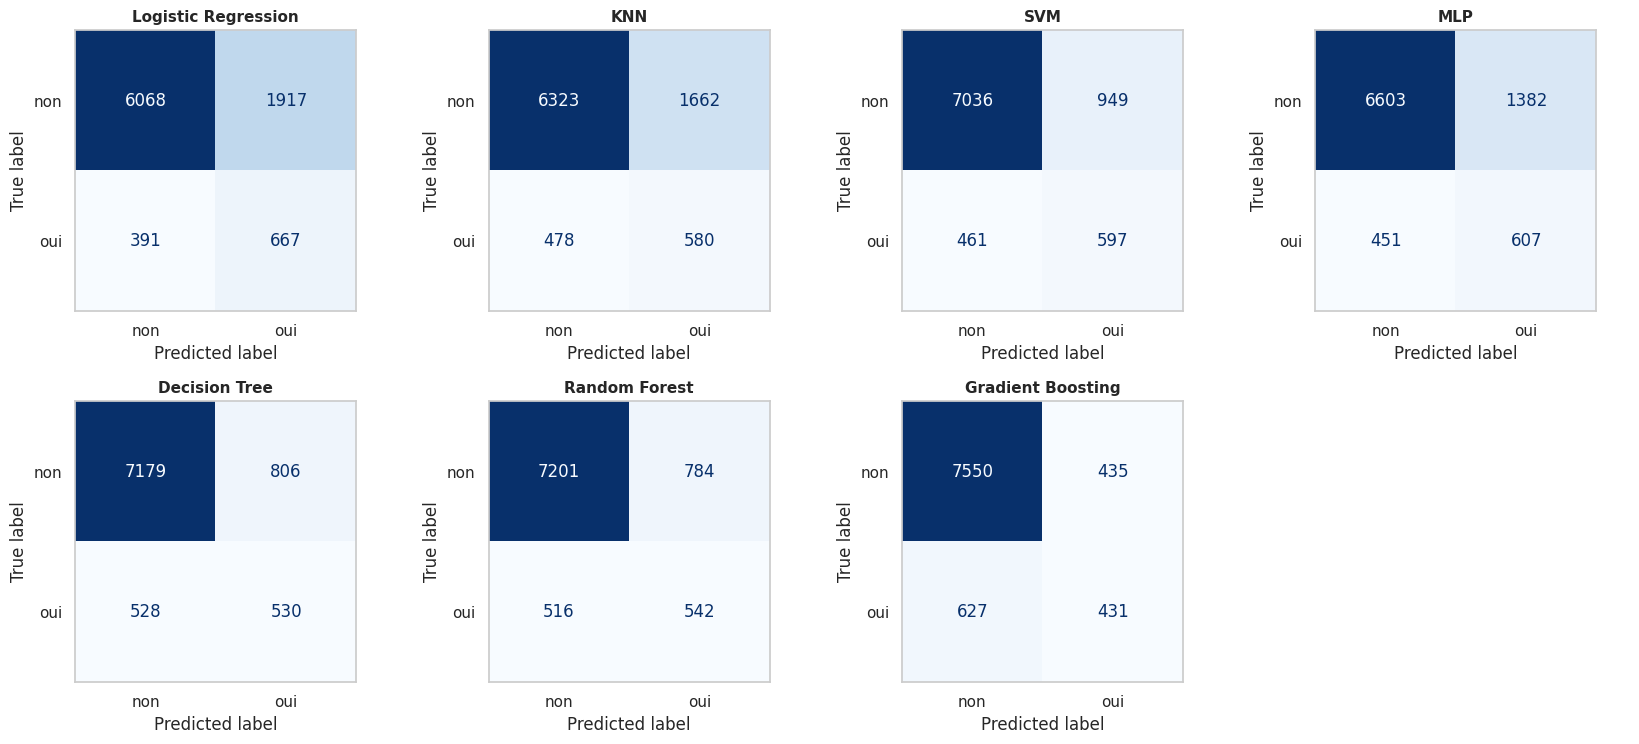

In [26]:
# Matrices de confusion (seuil par défaut du modèle)
n = len(models)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows))
axes = np.array(axes).flatten()
for ax, (nom, m) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, m.predict(X_test), ax=ax, colorbar=False,
                                            cmap="Blues", display_labels=["non", "oui"])
    ax.set_title(nom, fontweight="bold", fontsize=11); ax.grid(False)
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Vérification overfitting / underfitting

On compare le F1 sur le **train réel** (non rééquilibré) et sur le **test**. La comparaison est juste : les deux jeux ont la même distribution de classes (le jeu SMOTE, lui, a 50 % de « oui » et ne se compare pas au test).

Règle utilisée : écart > 0,10 → overfitting probable ; F1 test < 0,30 → underfitting probable.

,f1_train,f1,ecart,diagnostic
Random Forest,0.483,0.455,0.029,OK
Gradient Boosting,0.448,0.448,-0.000,OK
SVM,0.464,0.459,0.006,OK
Decision Tree,0.436,0.443,-0.007,OK
MLP,0.457,0.398,0.058,OK
Logistic Regression,0.369,0.366,0.003,OK
KNN,1.000,0.352,0.648,Overfitting probable


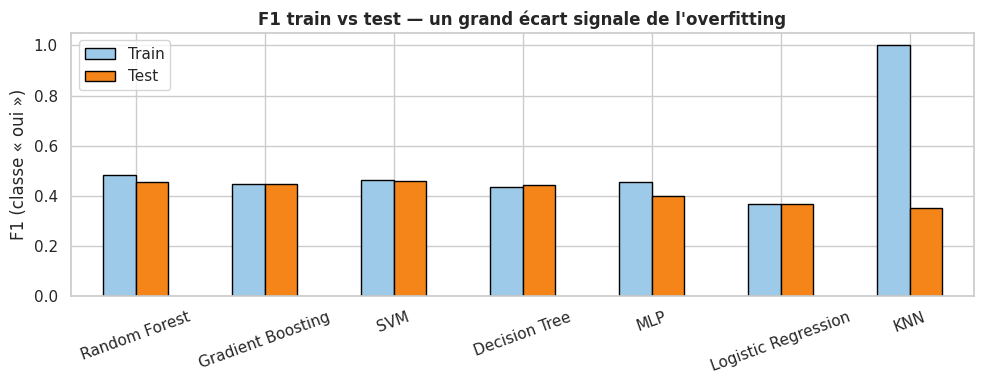

In [27]:
diag = df_res[["f1_train", "f1"]].copy()
diag["ecart"] = diag["f1_train"] - diag["f1"]
diag["diagnostic"] = np.where(diag["ecart"] > 0.10, "Overfitting probable",
                       np.where(diag["f1"] < 0.30, "Underfitting probable", "OK"))
display(diag.round(3))

ax = diag[["f1_train", "f1"]].plot.bar(figsize=(10, 4), rot=20, edgecolor="black", color=["#9ecae9", "#F58518"])
ax.set_ylabel("F1 (classe « oui »)"); ax.legend(["Train", "Test"])
ax.set_title("F1 train vs test — un grand écart signale de l'overfitting", fontweight="bold")
plt.tight_layout(); plt.show()

**Lecture :** six modèles sur sept ont un écart F1 train/test d'au plus 0,06 : pas d'overfitting marqué. Le KNN est signalé (F1 train = 1,00) : avec `weights='distance'`, chaque point d'entraînement est son propre plus proche voisin et est donc prédit parfaitement. L'écart est réel mais attendu pour cet algorithme, et son F1 test (0,35) reste le plus faible.

## 8. Choix du modèle et réglage du seuil

**Choix du modèle :** meilleur **F1 en validation croisée** parmi les modèles *déployables* (ceux qui fournissent des probabilités). On choisit sur la validation croisée et non sur le test, pour que le test reste une mesure honnête de la performance finale.

**Seuil de décision :** par défaut un modèle dit « oui » à partir de 50 % de probabilité. Ici, ce seuil n'est pas forcément le bon. On le règle sur des prédictions **out-of-fold** (validation croisée sur le train), puis on vérifie sur le test.

In [28]:
deployable = [n for n, m in models.items() if hasattr(m, "predict_proba")]
best_name = df_res.loc[deployable].sort_values("cv_f1", ascending=False).index[0]
final = models[best_name]
print(f"Modèle retenu : {best_name}")
print(df_res.loc[best_name, ["cv_f1", "precision", "recall", "f1", "roc_auc", "pr_auc"]].round(3).to_string())

Modèle retenu : Random Forest
cv_f1        0.443
precision    0.409
recall       0.512
f1           0.455
roc_auc      0.790
pr_auc       0.424


Seuil optimisé : 0.52


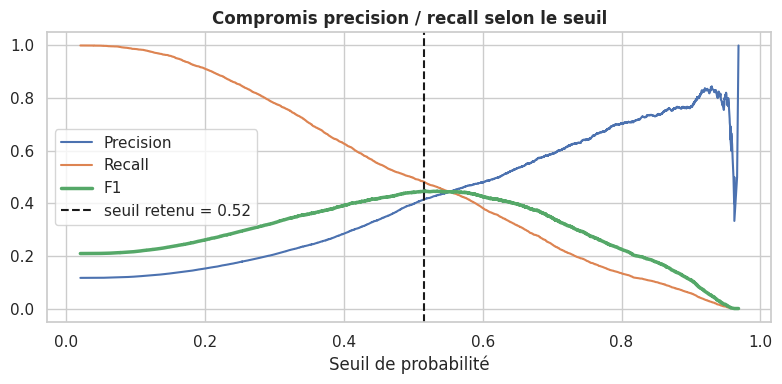

In [29]:
# Probabilités out-of-fold sur le train -> choix du seuil qui maximise le F1
oof = cross_val_predict(clone(final), X_train, y_train,
                        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                        method="predict_proba", n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
best_thr = float(thr[np.argmax(f1_curve[:-1])])
print(f"Seuil optimisé : {best_thr:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(thr, prec[:-1], label="Precision"); plt.plot(thr, rec[:-1], label="Recall")
plt.plot(thr, f1_curve[:-1], label="F1", lw=2.5)
plt.axvline(best_thr, color="k", ls="--", label=f"seuil retenu = {best_thr:.2f}")
plt.xlabel("Seuil de probabilité"); plt.title("Compromis precision / recall selon le seuil", fontweight="bold")
plt.legend(); plt.tight_layout(); plt.show()

,seuil,precision,recall,f1,% clients contactés
Seuil standard (0.5),0.500,0.409,0.512,0.455,0.147
Seuil optimisé,0.515,0.422,0.497,0.457,0.138


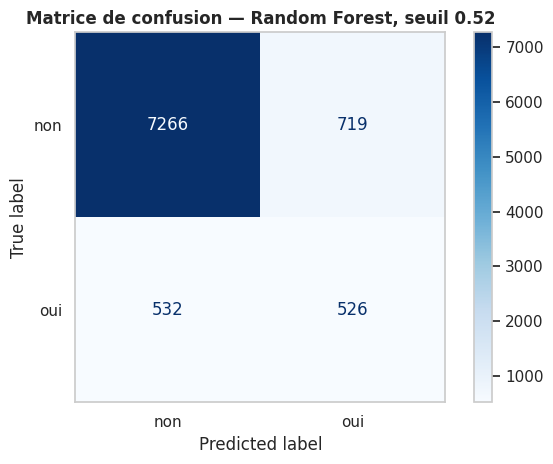

In [30]:
p_test = final.predict_proba(X_test)[:, 1]

def metrics_at(th):
    yp = (p_test >= th).astype(int)
    return {"seuil": th, "precision": precision_score(y_test, yp, zero_division=0),
            "recall": recall_score(y_test, yp), "f1": f1_score(y_test, yp),
            "% clients contactés": yp.mean()}

cmp_thr = pd.DataFrame([metrics_at(0.5), metrics_at(best_thr)],
                       index=["Seuil standard (0.5)", "Seuil optimisé"])
display(cmp_thr.round(3))

y_pred_final = (p_test >= best_thr).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, display_labels=["non", "oui"], cmap="Blues")
plt.title(f"Matrice de confusion — {best_name}, seuil {best_thr:.2f}", fontweight="bold")
plt.grid(False); plt.tight_layout(); plt.show()

**Lecture :** sur le test, le seuil optimisé (0,52) donne un F1 de 0,457 contre 0,455 à 0,50 : le gain est négligeable ici. L'intérêt du seuil est surtout de rendre le compromis explicite : à 0,52, le modèle signale 14 % des clients, avec une précision de 42 % et un recall de 50 % (526 souscripteurs détectés sur 1 058, pour 719 appels sans succès).

### 8.1 Gain business : combien de souscripteurs touche-t-on en appelant moins ?
On classe les clients du test du plus au moins probable, puis on regarde la part de souscripteurs captée en n'appelant que les mieux classés. La diagonale représente un ciblage au hasard.

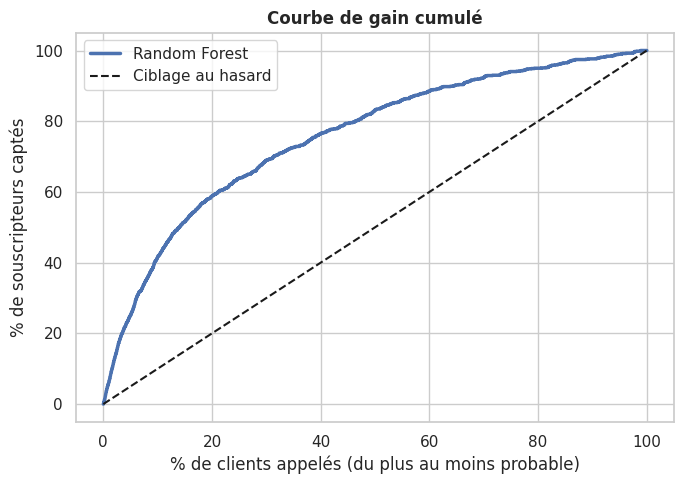

En appelant les 10% de clients les mieux classés -> 41% des souscripteurs captés
En appelant les 20% de clients les mieux classés -> 59% des souscripteurs captés
En appelant les 30% de clients les mieux classés -> 69% des souscripteurs captés
En appelant les 50% de clients les mieux classés -> 83% des souscripteurs captés


In [31]:
order = np.argsort(-p_test)
y_sorted = y_test.values[order]
cum_gain = np.cumsum(y_sorted) / y_sorted.sum()
pct_called = np.arange(1, len(y_sorted) + 1) / len(y_sorted)

gains = {f"{int(q * 100)}%": float(cum_gain[int(q * len(cum_gain)) - 1]) for q in (0.1, 0.2, 0.3, 0.5)}

plt.figure(figsize=(7, 5))
plt.plot(pct_called * 100, cum_gain * 100, lw=2.5, label=best_name)
plt.plot([0, 100], [0, 100], "k--", label="Ciblage au hasard")
plt.xlabel("% de clients appelés (du plus au moins probable)")
plt.ylabel("% de souscripteurs captés")
plt.title("Courbe de gain cumulé", fontweight="bold")
plt.legend(); plt.tight_layout(); plt.show()

for k, v in gains.items():
    print(f"En appelant les {k:>3} de clients les mieux classés -> {v:.0%} des souscripteurs captés")

**Lecture :** en appelant les 20 % de clients les mieux classés, on capte **59 %** des souscripteurs (20 % au hasard) ; avec 30 % des clients, 69 %. C'est le résultat le plus parlant pour un décideur.

### 8.2 Quelles variables comptent ?
Importance **par permutation** sur le test : on mélange une variable à la fois et on mesure la baisse du ROC-AUC. Contrairement aux importances internes des arbres, elle fonctionne avec n'importe quel modèle et se lit sur les colonnes d'origine.

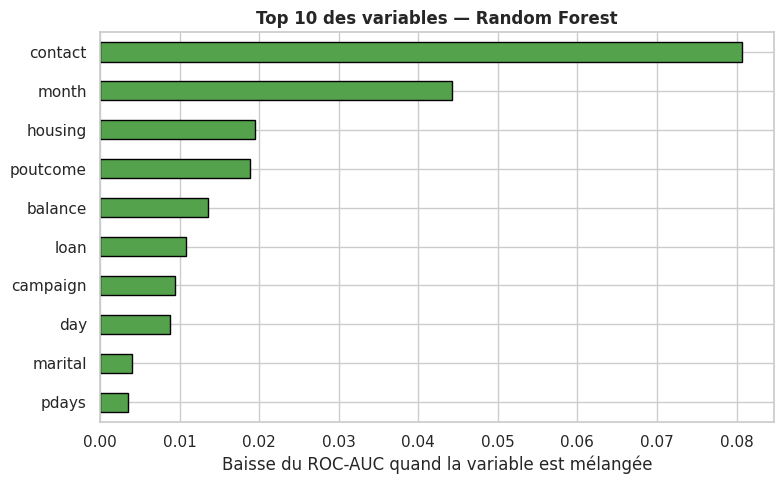

In [32]:
pi = permutation_importance(final, X_test, y_test, scoring="roc_auc", n_repeats=5,
                            random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values(ascending=False)

ax = imp.head(10).iloc[::-1].plot.barh(figsize=(8, 5), color="#54A24B", edgecolor="black")
ax.set_xlabel("Baisse du ROC-AUC quand la variable est mélangée")
ax.set_title(f"Top 10 des variables — {best_name}", fontweight="bold")
plt.tight_layout(); plt.show()

**Lecture :** les variables dont le mélange fait le plus baisser le ROC-AUC sont `contact` (type de contact, avec beaucoup de modalités « unknown »), `month`, `housing` et `poutcome`. À interpréter avec prudence : ce sont des associations, pas des causes ; `month` reflète aussi le calendrier des campagnes.

## 9. Sauvegarde pour le déploiement
Le **pipeline complet** (pré-traitement + modèle) est sauvegardé en un seul fichier : l'interface Streamlit lui envoie directement des données brutes. SMOTE est automatiquement ignoré à la prédiction.

Un fichier `metadata.json` conserve ce dont l'interface a besoin : variables, plages de valeurs, seuil, métriques, tableau de comparaison.

In [33]:
joblib.dump(final, MODELS_DIR / "pipeline.joblib")

num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(exclude="number").columns
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final).confusion_matrix
plt.close("all")
tn, fp, fn, tp = (int(v) for v in cm.ravel())

meta = {
    "model_name": best_name,
    "threshold": best_thr,
    "drop_duration": DROP_DURATION,
    "features": X_train.columns.tolist(),
    "numeric": {c: {"min": float(X_train[c].min()), "max": float(X_train[c].max()),
                    "median": float(X_train[c].median()),
                    "is_int": bool(pd.api.types.is_integer_dtype(X_train[c]))} for c in num_cols},
    "categorical": {c: {"options": sorted(X_train[c].unique().tolist()),
                        "default": str(X_train[c].mode()[0])} for c in cat_cols},
    "metrics_test": {k: float(v) for k, v in metrics_at(best_thr).items()}
                    | {"roc_auc": float(results[best_name]["roc_auc"]),
                       "pr_auc": float(results[best_name]["pr_auc"])},
    "confusion_matrix": {"tn": tn, "fp": fp, "fn": fn, "tp": tp},
    "gains": gains,
    "base_rate": float(y.mean()),
    "n_clients": int(len(df)),
    "importances": {k: float(v) for k, v in imp.head(10).round(4).items()},
    "comparison": df_res.round(4).reset_index(names="modele").to_dict(orient="records"),
    "sklearn_version": sklearn.__version__,
}
with open(MODELS_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Sauvegardé :", [p.name for p in MODELS_DIR.iterdir()])

Sauvegardé : ['pipeline.joblib', 'metadata.json']


In [34]:
# Test de rechargement : données brutes -> probabilité
pipe_loaded = joblib.load(MODELS_DIR / "pipeline.joblib")
exemple = X_test.iloc[[0]]
proba = pipe_loaded.predict_proba(exemple)[0, 1]
verdict = "à appeler en priorité" if proba >= best_thr else "faible priorité"
print(f"Client test #0 : probabilité de souscription = {proba:.1%} (seuil {best_thr:.0%}) -> {verdict} (réel : {'oui' if y_test.iloc[0] else 'non'})")
display(exemple)

Client test #0 : probabilité de souscription = 10.1% (seuil 52%) -> faible priorité (réel : non)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
1392,40,blue-collar,married,primary,no,640,yes,yes,unknown,8,may,2,-1,0,unknown


## 10. Conclusion

In [35]:
m = meta["metrics_test"]
print("RÉSUMÉ DU PROJET (chiffres calculés par ce notebook)")
print("-" * 60)
print(f"Données        : {len(df):,} clients, {X_train.shape[1]} variables, {y.mean():.1%} de souscripteurs")
print(f"Modèles testés : {len(models)} ({', '.join(models)})")
print(f"Modèle retenu  : {best_name}  (choisi sur la validation croisée)")
print(f"Test, seuil {best_thr:.2f} : precision {m['precision']:.0%} | recall {m['recall']:.0%} | F1 {m['f1']:.2f} | ROC-AUC {m['roc_auc']:.2f} | PR-AUC {m['pr_auc']:.2f}")
print(f"Ciblage        : appeler 20% des clients capte {gains['20%']:.0%} des souscripteurs (hasard : 20%)")
print(f"Top variables  : {', '.join(imp.head(3).index)}")
print(f"`duration` retiré : {'oui' if DROP_DURATION else 'non'}")

RÉSUMÉ DU PROJET (chiffres calculés par ce notebook)
------------------------------------------------------------
Données        : 45,211 clients, 15 variables, 11.7% de souscripteurs
Modèles testés : 7 (Logistic Regression, KNN, SVM, MLP, Decision Tree, Random Forest, Gradient Boosting)
Modèle retenu  : Random Forest  (choisi sur la validation croisée)
Test, seuil 0.52 : precision 42% | recall 50% | F1 0.46 | ROC-AUC 0.79 | PR-AUC 0.42
Ciblage        : appeler 20% des clients capte 59% des souscripteurs (hasard : 20%)
Top variables  : contact, month, housing
`duration` retiré : oui


### Ce que j'ai appris
- **Éviter la fuite de données :** split d'abord ; scaler, encodeur et SMOTE à l'intérieur d'un pipeline pour qu'ils soient ré-appris à chaque pli de validation croisée.
- **SMOTE hors du pipeline = scores trompeurs :** générer des exemples synthétiques avant la validation croisée fait fuiter de l'information vers les plis de validation.
- **Une variable peut être trop belle pour être vraie :** `duration` n'existe qu'après l'appel. Comparer avec et sans permet de le démontrer.
- **Choisir la bonne métrique :** sur des classes déséquilibrées, l'accuracy ment ; Recall, Precision, F1 et PR-AUC racontent la vraie histoire. Optimiser le recall seul donne un modèle qui dit « oui » à tout.
- **Le seuil rend le compromis explicite :** ici il change peu le F1 (0,455 → 0,457), mais il fixe clairement combien de clients on appelle et avec quelle précision ; avec des coûts réels, il se règle en euros.
- **Traduire en valeur :** la courbe de gain parle plus à un décideur qu'un F1.
- **Un modèle sert quand il est utilisable :** pipeline sauvegardé + interface Streamlit.

### Limites
- Données d'une seule banque et d'une période donnée : pas de garantie de généralisation à d'autres contextes ou à aujourd'hui.
- Pas de split temporel : un split chronologique serait plus réaliste.
- SMOTE appliqué après One-Hot Encoding (voir 4.4).
- Seuil optimisé sur le F1 : un vrai coût par appel et un vrai gain par souscription donneraient un seuil optimisé en euros.

### Pistes
`SMOTENC` ou `class_weight` à la place de SMOTE · XGBoost / LightGBM · explications locales avec SHAP · calibration des probabilités · seuil basé sur un coût métier · API de scoring.